# Decision Tree Analysis: Women in the Labor Market (Latin America)

**Objective:** Identify the most important predictors of barriers women face in the labor market across Latin American countries, using World Bank data.

**Targets analyzed:**
- Female unemployment rate (`SL.UEM.TOTL.FE.ZS`)
- Female share in senior/middle management (`SL.EMP.SMGT.FE.ZS`)
- Firms with female top manager (`IC.FRM.FEMM.ZS`)
- Women in national parliament (`SG.GEN.PARL.ZS`)
- Women Business and Law Index (`SG.LAW.INDX`)
- Female labor force participation (`SL.TLF.CACT.FE.ZS`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2')

## 1. Load and Reshape Data

In [2]:
df_long = pd.read_csv('../extraction/data/wb_women_latam_long.csv')
print(f'Shape (long): {df_long.shape}')
print(f'Countries: {sorted(df_long.country_code.unique())}')
print(f'Years: {sorted(df_long.year.unique())}')
print(f'Indicators: {df_long.indicator_code.nunique()}')

Shape (long): (5152, 6)
Countries: ['ARG', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'CUB', 'DOM', 'ECU', 'GTM', 'HND', 'MEX', 'NIC', 'PAN', 'PER', 'PRY', 'SLV', 'URY', 'VEN']
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Indicators: 79


In [3]:
# Pivot to wide format: rows = (country, year), columns = indicators
df_wide = df_long.pivot_table(
    index=['country_code', 'country_name', 'year'],
    columns='indicator_code',
    values='value'
).reset_index()
df_wide.columns.name = None

print(f'Shape (wide): {df_wide.shape}')
print(f'\nMissing values per column (top 15):')
print(df_wide.isnull().sum().sort_values(ascending=False).head(15))

Shape (wide): (95, 82)

Missing values per column (top 15):
SG.TIM.UWRK.MA          93
SG.TIM.UWRK.FE          93
IC.FRM.FEMO.ZS          87
IC.FRM.FEMM.ZS          87
SE.TER.CUAT.DO.FE.ZS    80
SE.TER.CUAT.DO.MA.ZS    79
HD_HCIP_OVRL_FE         79
HD_HCIP_OVRL_TO         79
HD_HCIP_OVRL_MA         79
HD_HCIP_EDUC_FE         78
HD_HCIP_EDUC_MA         78
HD_HCIP_EDUC_TO         78
HD_HCIP_OTJL_MA         77
HD_HCIP_OTJL_TO         77
HD_HCIP_OTJL_FE         77
dtype: int64


In [4]:
# Human-readable short names for indicators
label_map = {
    'SL.TLF.CACT.FE.ZS': 'LFPR_female',
    'SL.TLF.CACT.MA.ZS': 'LFPR_male',
    'SL.UEM.TOTL.FE.ZS': 'Unemp_female',
    'SL.UEM.TOTL.MA.ZS': 'Unemp_male',
    'SL.EMP.VULN.FE.ZS': 'VulnEmp_female',
    'SL.EMP.VULN.MA.ZS': 'VulnEmp_male',
    'SL.EMP.SELF.FE.ZS': 'SelfEmp_female',
    'SL.EMP.MPYR.FE.ZS': 'Employers_female',
    'SL.EMP.MPYR.MA.ZS': 'Employers_male',
    'SL.EMP.WORK.FE.ZS': 'WageSalaried_female',
    'SL.AGR.EMPL.FE.ZS': 'EmpAgriculture_female',
    'SL.IND.EMPL.FE.ZS': 'EmpIndustry_female',
    'SL.SRV.EMPL.FE.ZS': 'EmpServices_female',
    'SL.EMP.SMGT.FE.ZS': 'SeniorMgmt_female',
    'SE.ADT.LITR.FE.ZS': 'Literacy_female',
    'SE.ADT.LITR.MA.ZS': 'Literacy_male',
    'SE.SEC.ENRR.FE':    'SecondaryEnroll_female',
    'SE.TER.ENRR.FE':    'TertiaryEnroll_female',
    'SE.TER.CUAT.BA.FE.ZS': 'BachelorAttain_female',
    'SE.TER.CUAT.BA.MA.ZS': 'BachelorAttain_male',
    'SE.SEC.CUAT.UP.FE.ZS': 'UpperSecAttain_female',
    'SE.SEC.CUAT.UP.MA.ZS': 'UpperSecAttain_male',
    'SP.DYN.TFRT.IN':    'FertilityRate',
    'SP.ADO.TFRT':       'AdolescentFertility',
    'SH.STA.MMRT':       'MaternalMortality',
    'SG.GEN.PARL.ZS':   'WomenParliament',
    'IC.FRM.FEMM.ZS':   'FemaleTopManager',
    'IC.FRM.FEMO.ZS':   'FemaleOwnership',
    'SG.LAW.INDX':      'WomenLawIndex',
    'AG.LND.AGRI.ZS':   'AgriculturalLand',
    'IT.NET.USER.FE.ZS':'Internet_female',
    'IT.NET.USER.MA.ZS':'Internet_male',
    'SG.TIM.UWRK.FE':   'UnpaidWork_female',
    'SG.TIM.UWRK.MA':   'UnpaidWork_male',
    'SL.TLF.PART.FE.ZS':'PartTime_female',
    'SL.TLF.PART.MA.ZS':'PartTime_male',
    'SL.FAM.WORK.FE.ZS':'FamilyWorkers_female',
    'SL.TLF.ADVN.FE.ZS':'AdvancedEdLF_female',
    'SL.TLF.ADVN.MA.ZS':'AdvancedEdLF_male',
    'SL.TLF.BASC.FE.ZS':'BasicEdLF_female',
    'SL.TLF.INTM.FE.ZS':'IntermEdLF_female',
    'HD_HCIP_OVRL_FE':  'HCI_female',
    'HD_HCIP_OVRL_MA':  'HCI_male',
    'HD_HCIP_EDUC_FE':  'HCI_educ_female',
    'HD_HCIP_HLTH_FE':  'HCI_health_female',
    'HD_HCIP_OTJL_FE':  'HCI_OJL_female',
    'SE.PRE.ENRR.FE':   'PreprimaryEnroll_female',
    'SE.PRM.CMPT.FE.ZS':'PrimaryCompletion_female',
    'SE.PRM.CMPT.MA.ZS':'PrimaryCompletion_male',
    'SE.PRM.UNER.FE.ZS':'OutOfSchool_female',
    'SE.PRM.UNER.MA.ZS':'OutOfSchool_male',
}

cols_to_rename = {k: v for k, v in label_map.items() if k in df_wide.columns}
df = df_wide.rename(columns=cols_to_rename)
print('Renamed', len(cols_to_rename), 'columns')
df.head(3)

Renamed 51 columns


,country_code,country_name,year,AgriculturalLand,HCI_educ_female,HD_HCIP_EDUC_MA,HD_HCIP_EDUC_TO,HCI_health_female,HD_HCIP_HLTH_MA,HD_HCIP_HLTH_TO,...,LFPR_female,LFPR_male,IntermEdLF_female,SL.TLF.INTM.MA.ZS,PartTime_female,PartTime_male,Unemp_female,Unemp_male,AdolescentFertility,FertilityRate
0,ARG,Argentina,2020,43.000486,113.790446,105.564182,109.745517,45.892786,44.031581,44.946071,...,46.486,65.925,51.231,72.713,63.48,40.71,12.394,10.778,31.492,1.601
1,ARG,Argentina,2021,43.109742,NaN,NaN,NaN,NaN,NaN,NaN,...,50.260,70.836,55.356,77.649,57.53,32.07,9.852,7.915,28.540,1.585
2,ARG,Argentina,2022,43.427644,NaN,NaN,NaN,NaN,NaN,NaN,...,51.868,71.453,56.641,77.993,55.69,29.80,7.682,6.145,25.767,1.482


## 2. Define Targets and Feature Pool

In [5]:
# Targets: indicators of barriers women face
TARGETS = {
    'Unemp_female':      'Female Unemployment Rate (%)',
    'SeniorMgmt_female': 'Female Share in Senior/Middle Mgmt (%)',
    'FemaleTopManager':  'Firms with Female Top Manager (%)',
    'WomenParliament':   'Women in Parliament (%)',
    'WomenLawIndex':     'Women Business & Law Index (0-100)',
    'LFPR_female':       'Female Labor Force Participation Rate (%)',
}

# Feature pool: structural, socioeconomic, and demographic predictors
FEATURES = [
    # Education
    'Literacy_female', 'Literacy_male',
    'TertiaryEnroll_female', 'SecondaryEnroll_female',
    'BachelorAttain_female', 'BachelorAttain_male',
    'UpperSecAttain_female', 'UpperSecAttain_male',
    'AdvancedEdLF_female', 'AdvancedEdLF_male',
    'PrimaryCompletion_female', 'OutOfSchool_female',
    # Fertility / demographics
    'FertilityRate', 'AdolescentFertility', 'MaternalMortality',
    # Work patterns
    'VulnEmp_female', 'SelfEmp_female',
    'EmpAgriculture_female', 'EmpServices_female', 'EmpIndustry_female',
    'FamilyWorkers_female', 'PartTime_female',
    'UnpaidWork_female', 'UnpaidWork_male',
    # Institutional
    'AgriculturalLand',
    # Technology
    'Internet_female', 'Internet_male',
    # Human capital
    'HCI_female', 'HCI_male',
    'HCI_educ_female', 'HCI_health_female', 'HCI_OJL_female',
    # Ownership / entrepreneurship
    'FemaleOwnership', 'Employers_female', 'Employers_male',
    # Time trend
    'year',
]

FEATURES = [f for f in FEATURES if f in df.columns]
print(f'{len(FEATURES)} features available:', FEATURES)

36 features available: ['Literacy_female', 'Literacy_male', 'TertiaryEnroll_female', 'SecondaryEnroll_female', 'BachelorAttain_female', 'BachelorAttain_male', 'UpperSecAttain_female', 'UpperSecAttain_male', 'AdvancedEdLF_female', 'AdvancedEdLF_male', 'PrimaryCompletion_female', 'OutOfSchool_female', 'FertilityRate', 'AdolescentFertility', 'MaternalMortality', 'VulnEmp_female', 'SelfEmp_female', 'EmpAgriculture_female', 'EmpServices_female', 'EmpIndustry_female', 'FamilyWorkers_female', 'PartTime_female', 'UnpaidWork_female', 'UnpaidWork_male', 'AgriculturalLand', 'Internet_female', 'Internet_male', 'HCI_female', 'HCI_male', 'HCI_educ_female', 'HCI_health_female', 'HCI_OJL_female', 'FemaleOwnership', 'Employers_female', 'Employers_male', 'year']


## 3. Helper Functions

In [6]:
def prepare_XY(df, target, features):
    """Drop high-missing features, return complete-case X, y."""
    subset = df[features + [target]].dropna(subset=[target])
    miss = subset[features].isnull().mean()
    good_feats = miss[miss <= 0.4].index.tolist()
    subset = subset[good_feats + [target]].dropna()
    return subset[good_feats], subset[target], good_feats


def train_evaluate(X, y, feat_names, target_label, n_top=15):
    """Train RandomForest + DecisionTree, compute CV-R2 and permutation importances."""
    cv = LeaveOneOut() if len(y) < 50 else 5

    # Random Forest — stable feature importances
    rf = RandomForestRegressor(n_estimators=300, max_depth=4,
                                min_samples_leaf=3, random_state=42)
    rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2')
    rf.fit(X, y)

    perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42)
    imp_df = pd.DataFrame({
        'feature':         feat_names,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
    }).sort_values('importance_mean', ascending=False).head(n_top)

    # Single Decision Tree — for visual interpretation
    dt = DecisionTreeRegressor(max_depth=4, min_samples_leaf=4, random_state=42)
    dt_scores = cross_val_score(dt, X, y, cv=cv, scoring='r2')
    dt.fit(X, y)

    print(f"\n{'='*60}")
    print(f"Target : {target_label}  (n={len(y)})")
    print(f"  RandomForest CV-R²: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
    print(f"  DecisionTree CV-R²: {dt_scores.mean():.3f} ± {dt_scores.std():.3f}")

    return rf, dt, imp_df, feat_names


def plot_importance(imp_df, target_label, ax, color):
    imp_plot = imp_df[imp_df.importance_mean > 0].copy()
    ax.barh(imp_plot.feature[::-1], imp_plot.importance_mean[::-1],
            xerr=imp_plot.importance_std[::-1],
            color=color, alpha=0.85, capsize=3)
    ax.set_xlabel('Permutation Importance (mean ± std)')
    ax.set_title(target_label, fontsize=10, fontweight='bold')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.tick_params(axis='y', labelsize=9)

## 4. Train Models and Extract Feature Importances

In [7]:
results = {}  # target_key -> (rf, dt, imp_df, feat_names, X, y)

for target_key, target_label in TARGETS.items():
    if target_key not in df.columns:
        print(f'SKIP {target_key}: column not found')
        continue

    feats = [f for f in FEATURES if f != target_key]
    X, y, good_feats = prepare_XY(df, target_key, feats)

    if len(y) < 15:
        print(f'SKIP {target_key}: only {len(y)} complete rows')
        continue

    rf, dt, imp_df, feat_names = train_evaluate(X, y, good_feats, target_label)
    results[target_key] = (rf, dt, imp_df, feat_names, X, y)


Target : Female Unemployment Rate (%)  (n=32)
  RandomForest CV-R²: nan ± nan
  DecisionTree CV-R²: nan ± nan

Target : Female Share in Senior/Middle Mgmt (%)  (n=22)
  RandomForest CV-R²: nan ± nan
  DecisionTree CV-R²: nan ± nan
SKIP FemaleTopManager: only 4 complete rows

Target : Women in Parliament (%)  (n=32)
  RandomForest CV-R²: nan ± nan
  DecisionTree CV-R²: nan ± nan

Target : Women Business & Law Index (0-100)  (n=25)
  RandomForest CV-R²: nan ± nan
  DecisionTree CV-R²: nan ± nan

Target : Female Labor Force Participation Rate (%)  (n=32)
  RandomForest CV-R²: nan ± nan
  DecisionTree CV-R²: nan ± nan


## 5. Feature Importance Plots (All Targets)

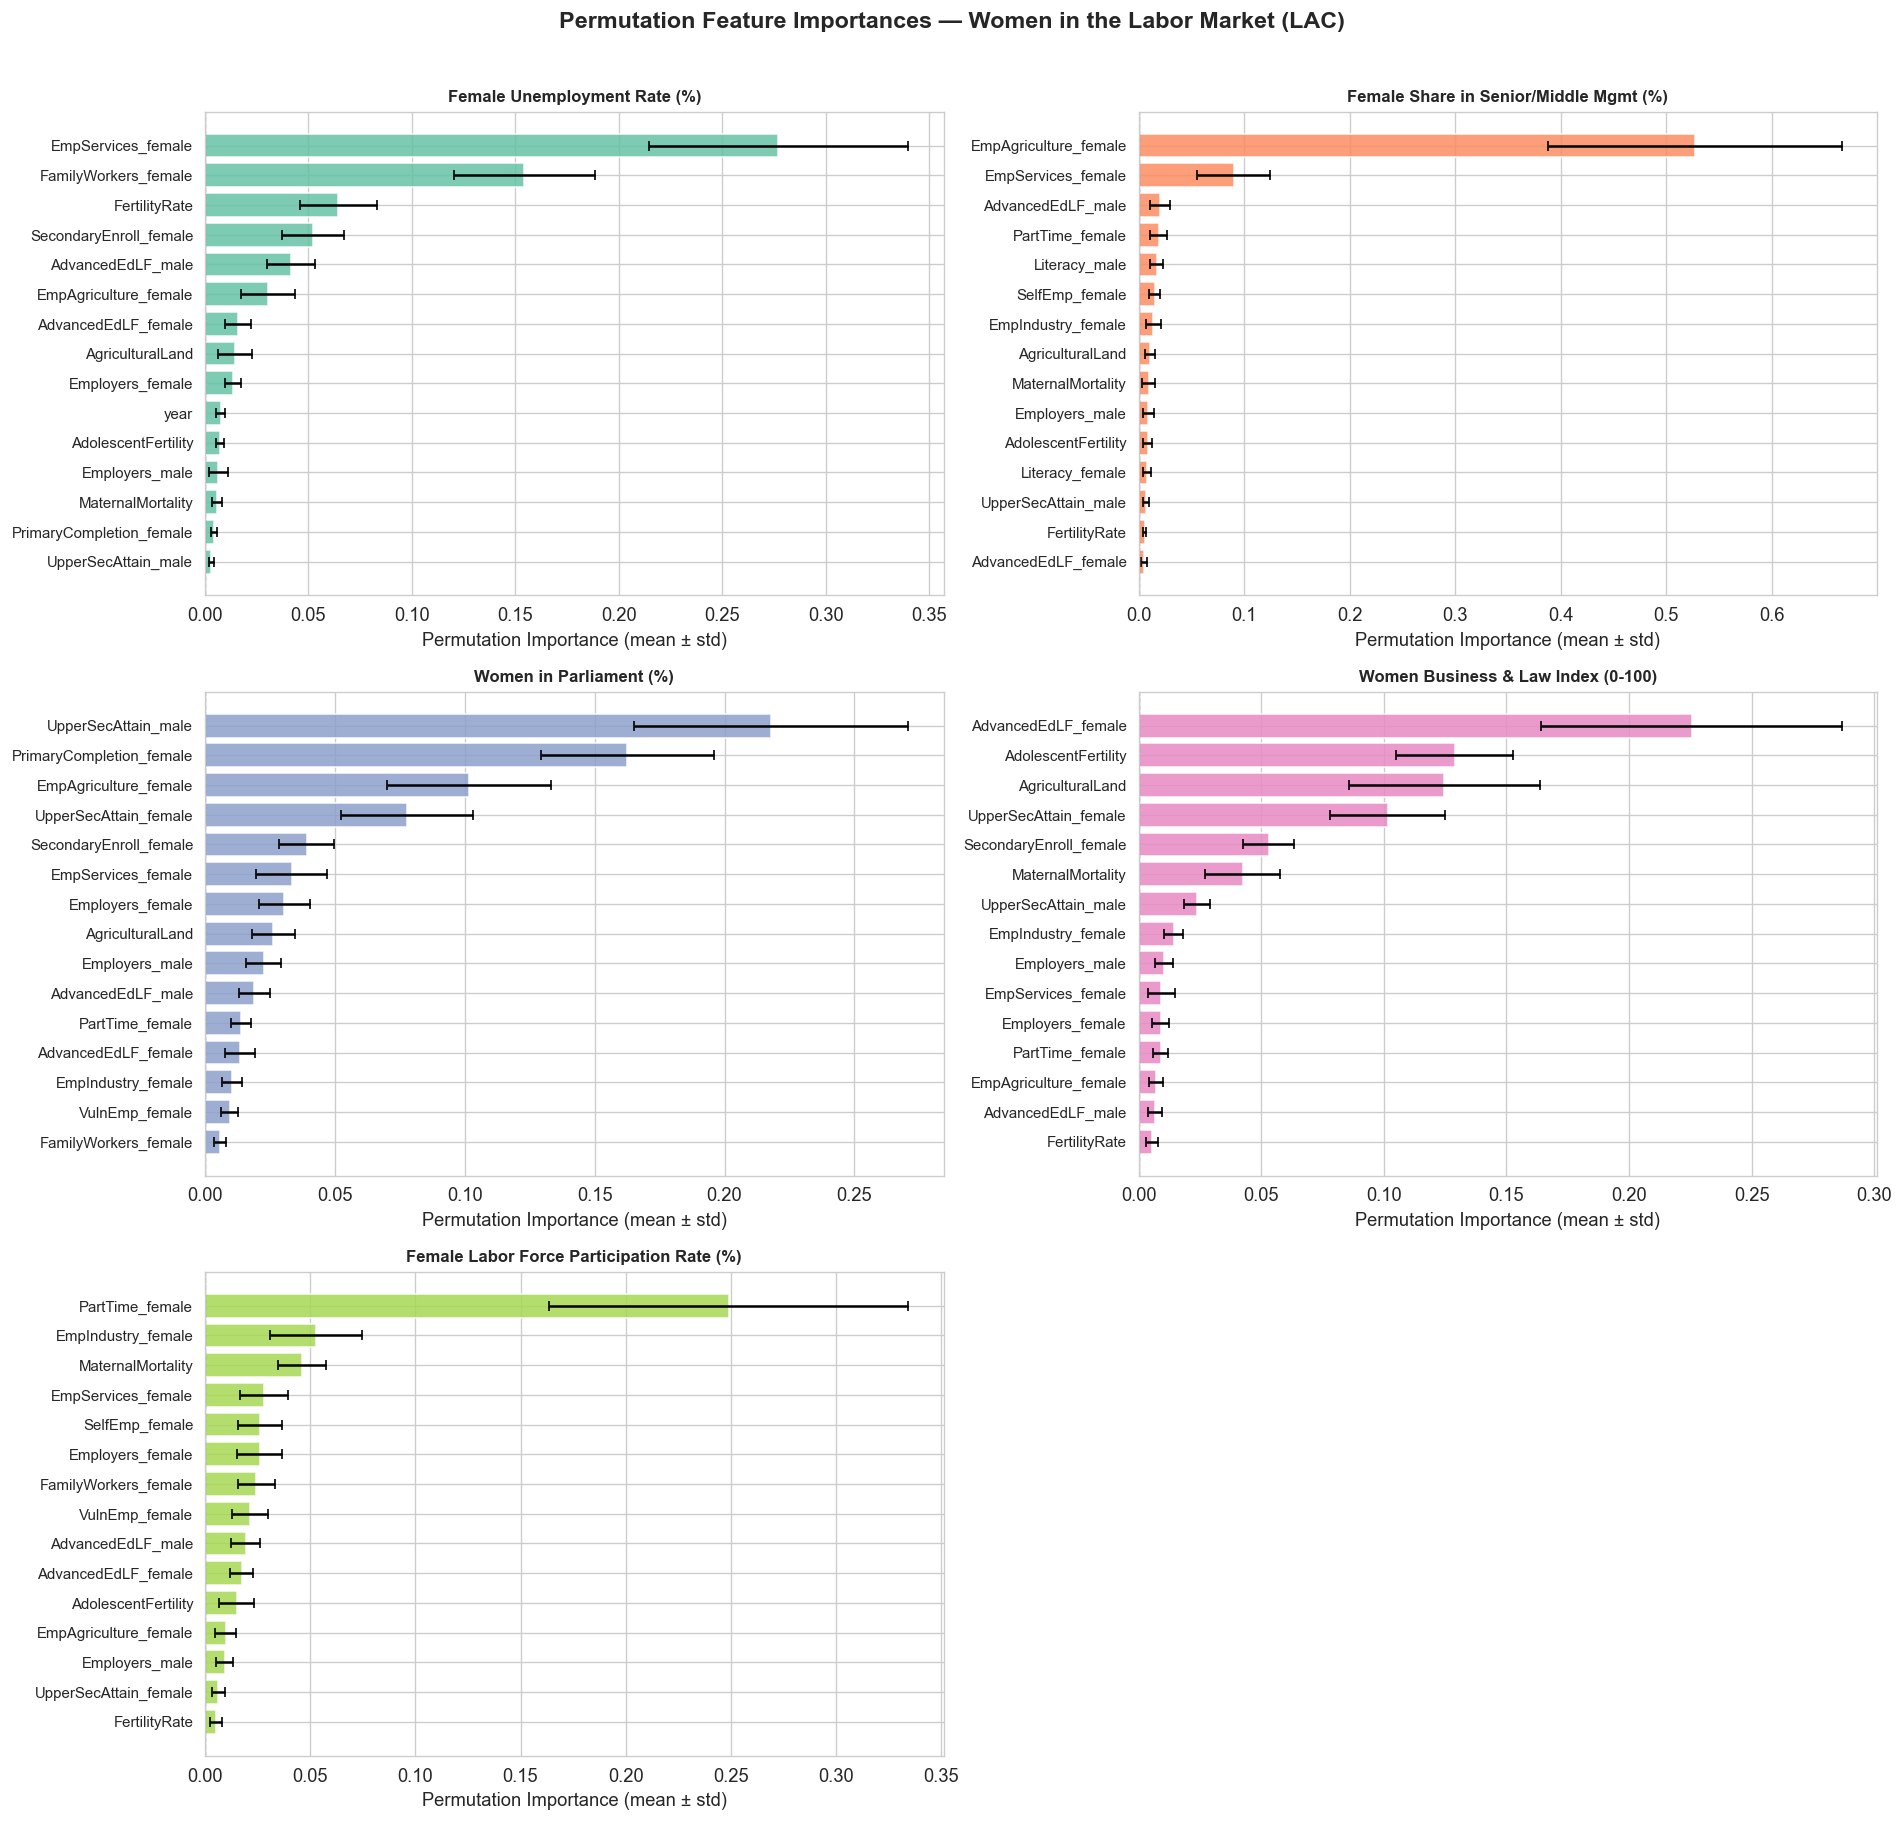

In [8]:
n_targets = len(results)
ncols = 2
nrows = (n_targets + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = axes.flatten()
colors = sns.color_palette('Set2', n_targets)

for idx, (target_key, (rf, dt, imp_df, feat_names, X, y)) in enumerate(results.items()):
    plot_importance(imp_df, TARGETS[target_key], axes[idx], colors[idx])

for ax in axes[n_targets:]:
    ax.set_visible(False)

plt.suptitle('Permutation Feature Importances — Women in the Labor Market (LAC)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Decision Tree Visualizations

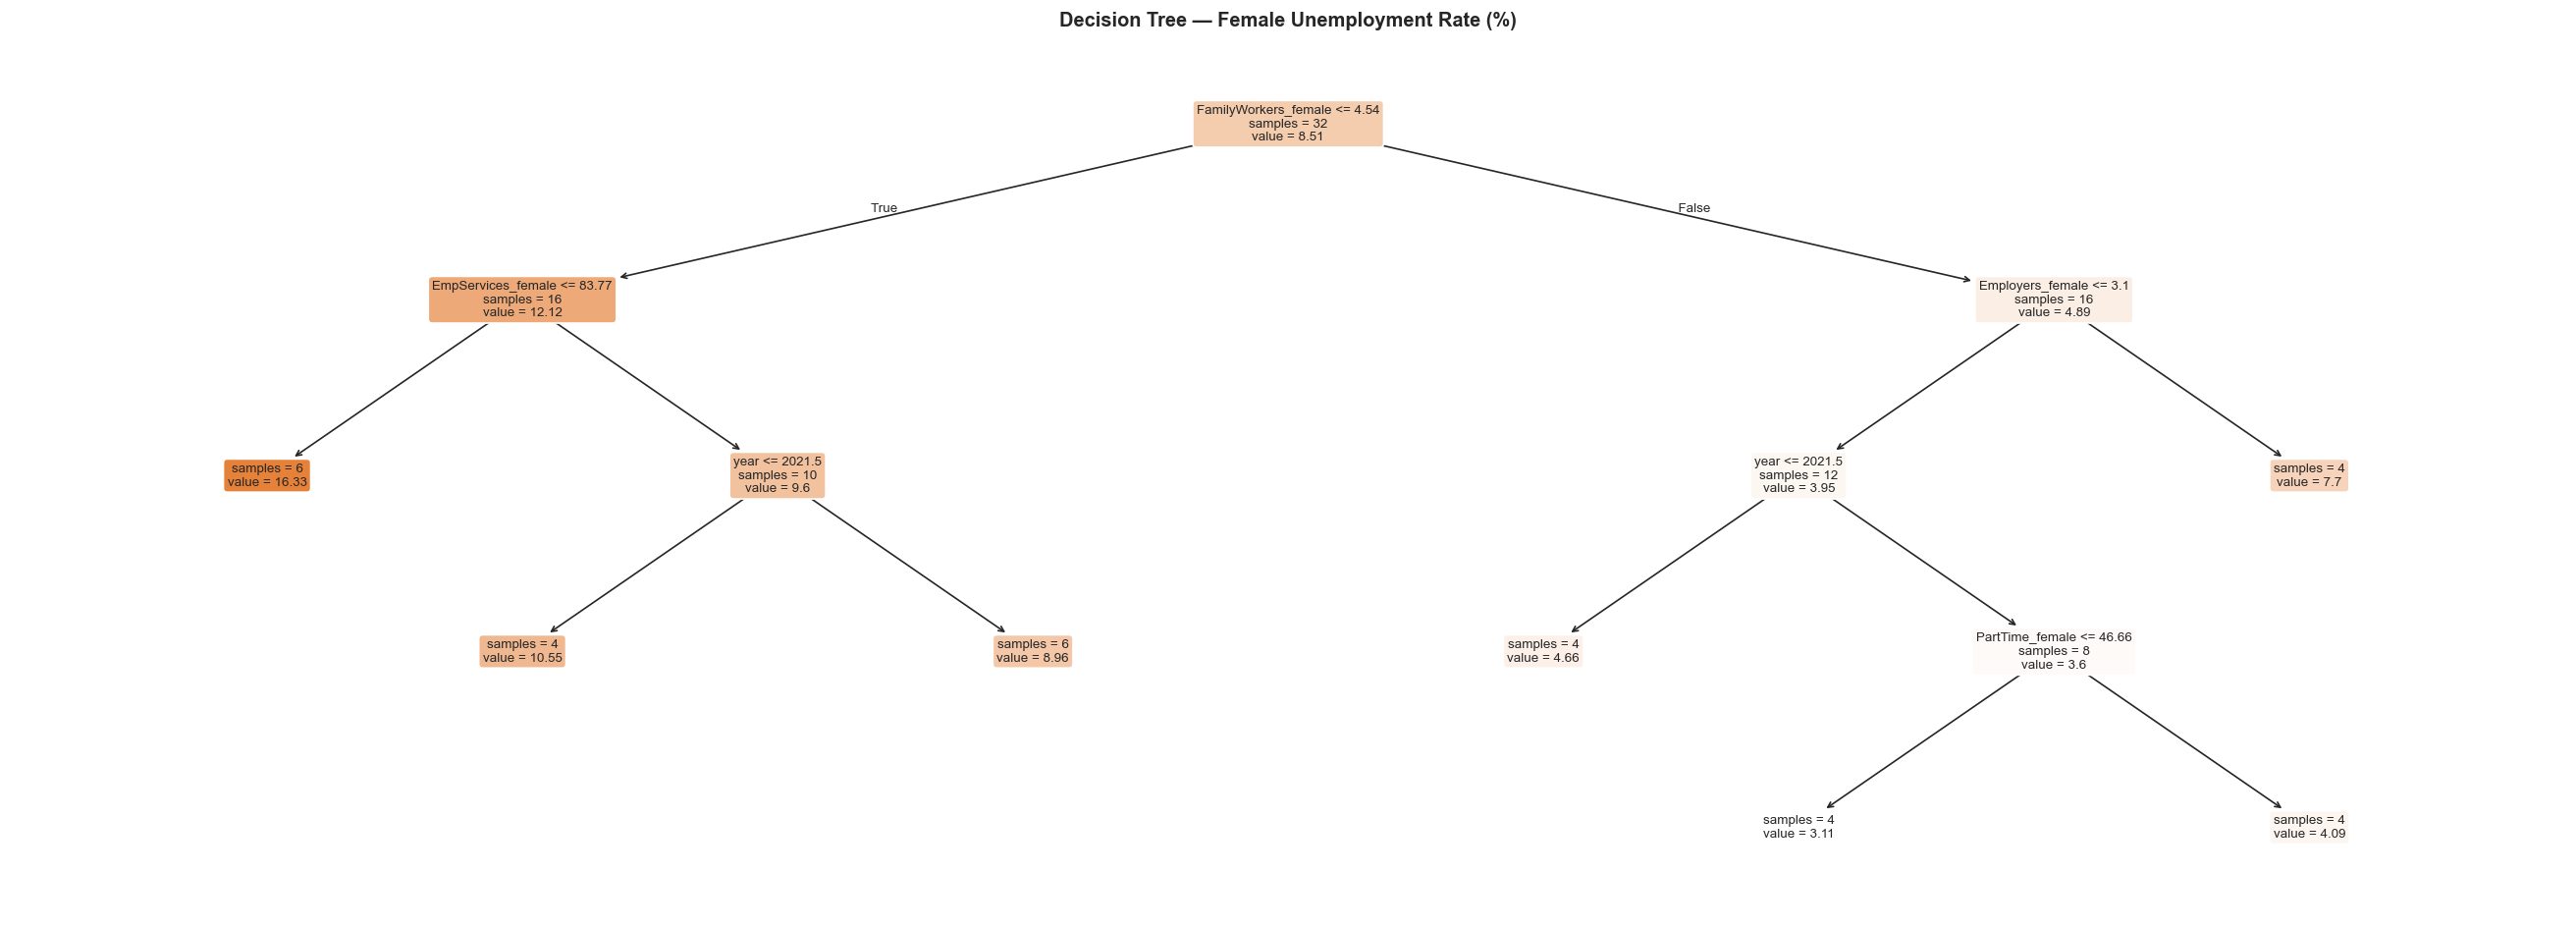


--- Rules: Female Unemployment Rate (%) ---
|--- FamilyWorkers_female <= 4.54
|   |--- EmpServices_female <= 83.77
|   |   |--- value: [16.33]
|   |--- EmpServices_female >  83.77
|   |   |--- year <= 2021.50
|   |   |   |--- value: [10.55]
|   |   |--- year >  2021.50
|   |   |   |--- value: [8.96]
|--- FamilyWorkers_female >  4.54
|   |--- Employers_female <= 3.10
|   |   |--- year <= 2021.50
|   |   |   |--- value: [4.66]
|   |   |--- year >  2021.50
|   |   |   |--- PartTime_female <= 46.66
|   |   |   |   |--- value: [3.11]
|   |   |   |--- PartTime_female >  46.66
|   |   |   |   |--- value: [4.09]
|   |--- Employers_female >  3.10
|   |   |--- value: [7.70]



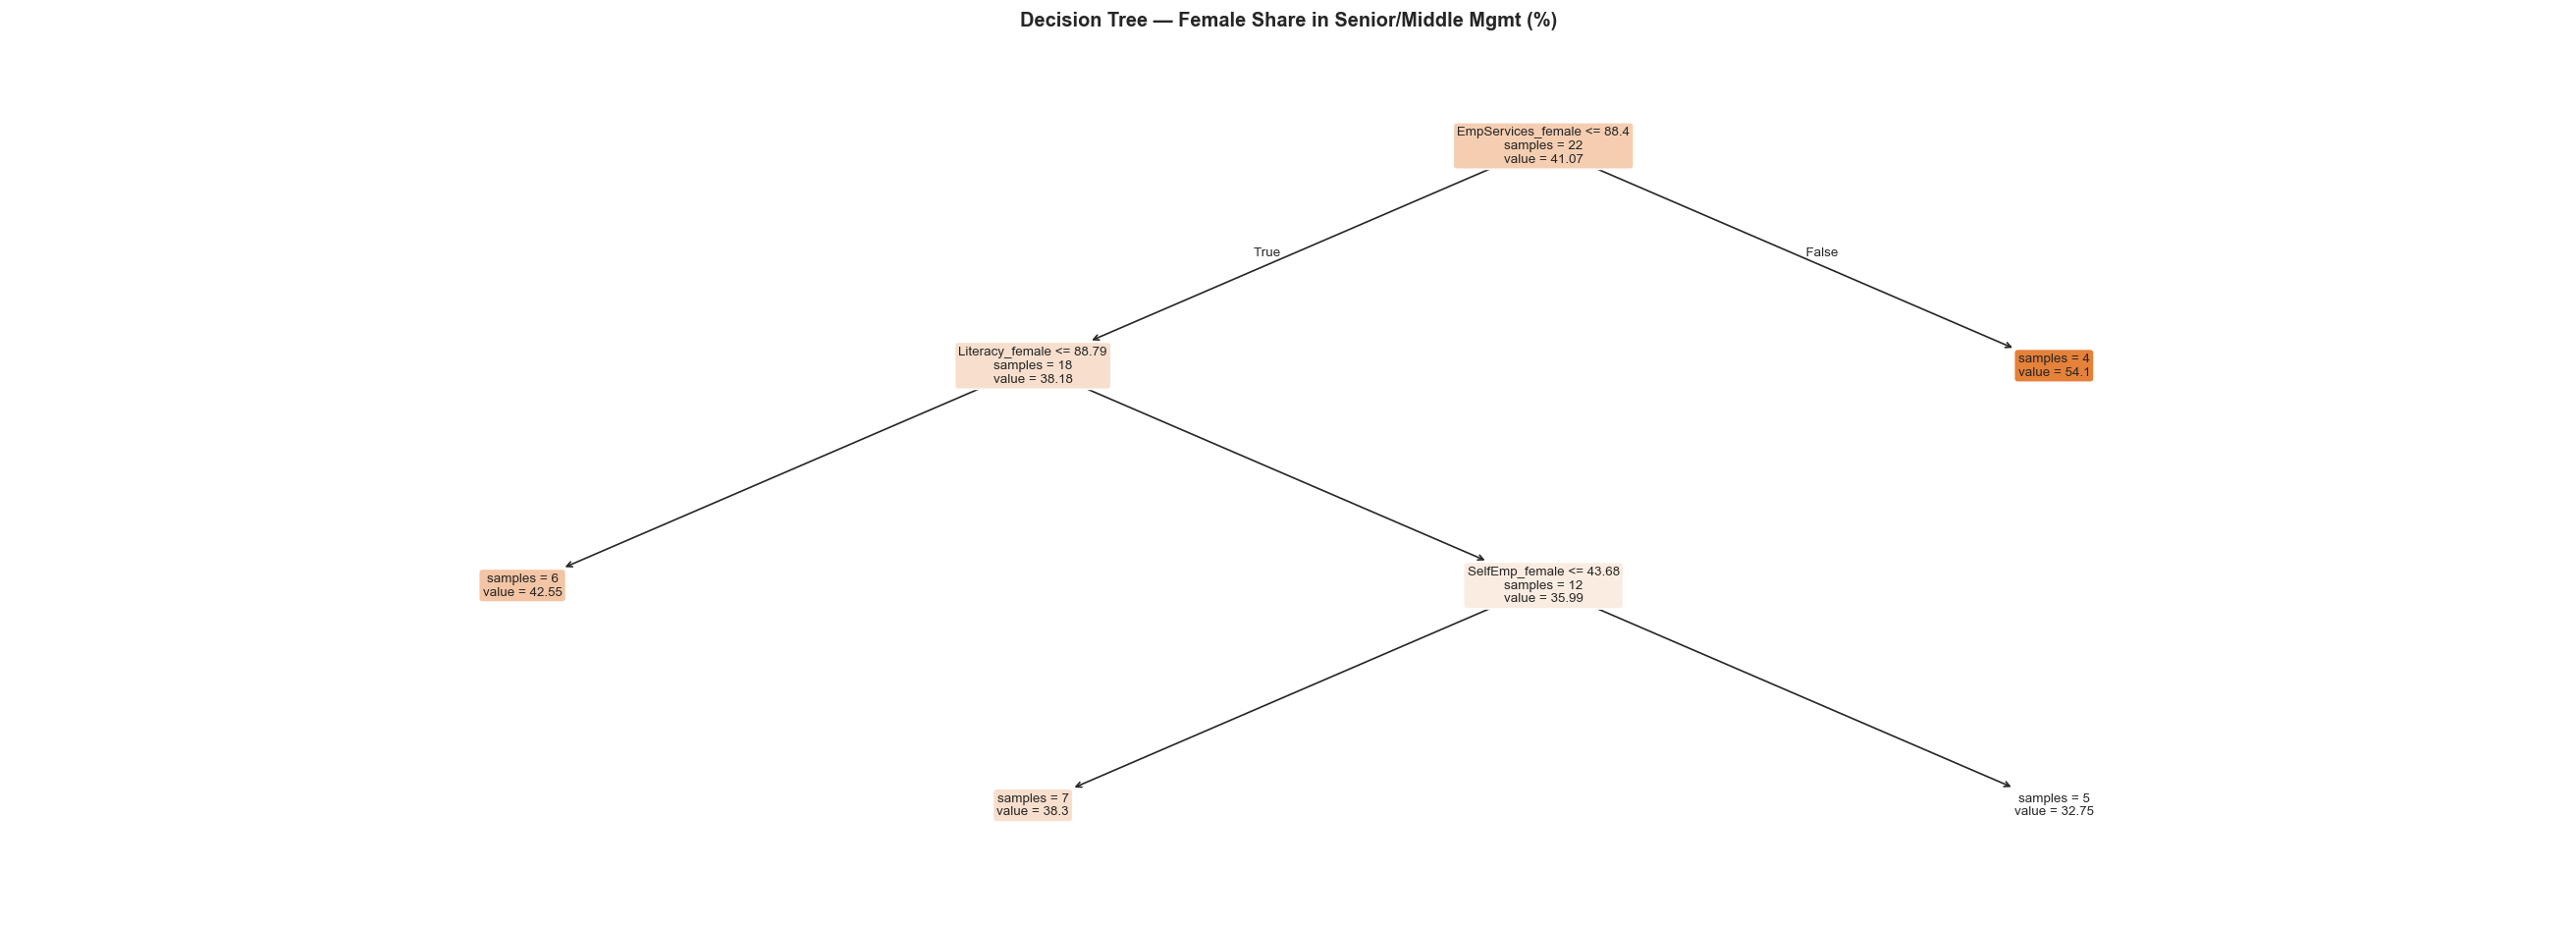


--- Rules: Female Share in Senior/Middle Mgmt (%) ---
|--- EmpServices_female <= 88.40
|   |--- Literacy_female <= 88.79
|   |   |--- value: [42.55]
|   |--- Literacy_female >  88.79
|   |   |--- SelfEmp_female <= 43.68
|   |   |   |--- value: [38.30]
|   |   |--- SelfEmp_female >  43.68
|   |   |   |--- value: [32.75]
|--- EmpServices_female >  88.40
|   |--- value: [54.10]



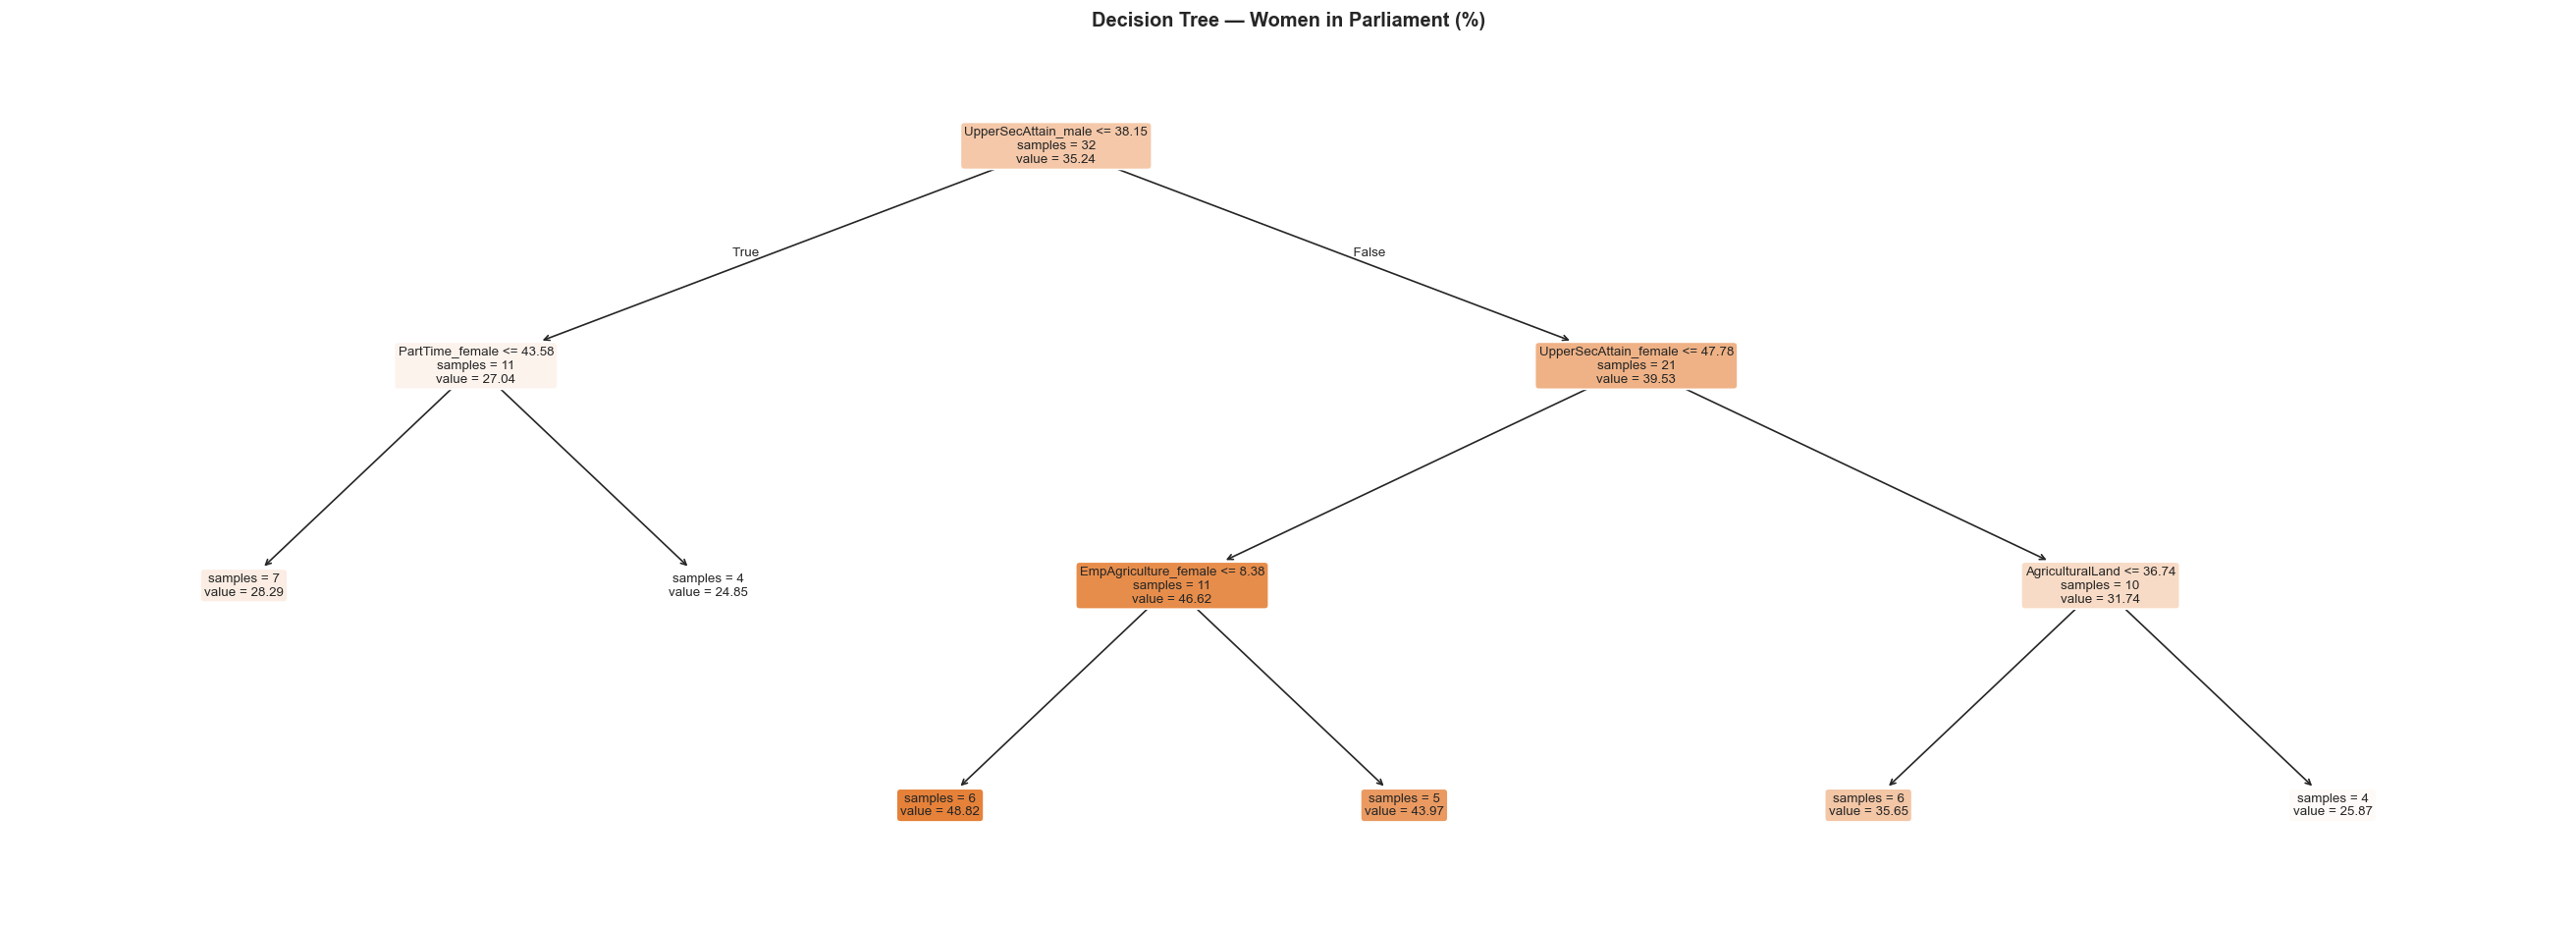


--- Rules: Women in Parliament (%) ---
|--- UpperSecAttain_male <= 38.15
|   |--- PartTime_female <= 43.58
|   |   |--- value: [28.29]
|   |--- PartTime_female >  43.58
|   |   |--- value: [24.85]
|--- UpperSecAttain_male >  38.15
|   |--- UpperSecAttain_female <= 47.78
|   |   |--- EmpAgriculture_female <= 8.38
|   |   |   |--- value: [48.82]
|   |   |--- EmpAgriculture_female >  8.38
|   |   |   |--- value: [43.97]
|   |--- UpperSecAttain_female >  47.78
|   |   |--- AgriculturalLand <= 36.74
|   |   |   |--- value: [35.65]
|   |   |--- AgriculturalLand >  36.74
|   |   |   |--- value: [25.87]



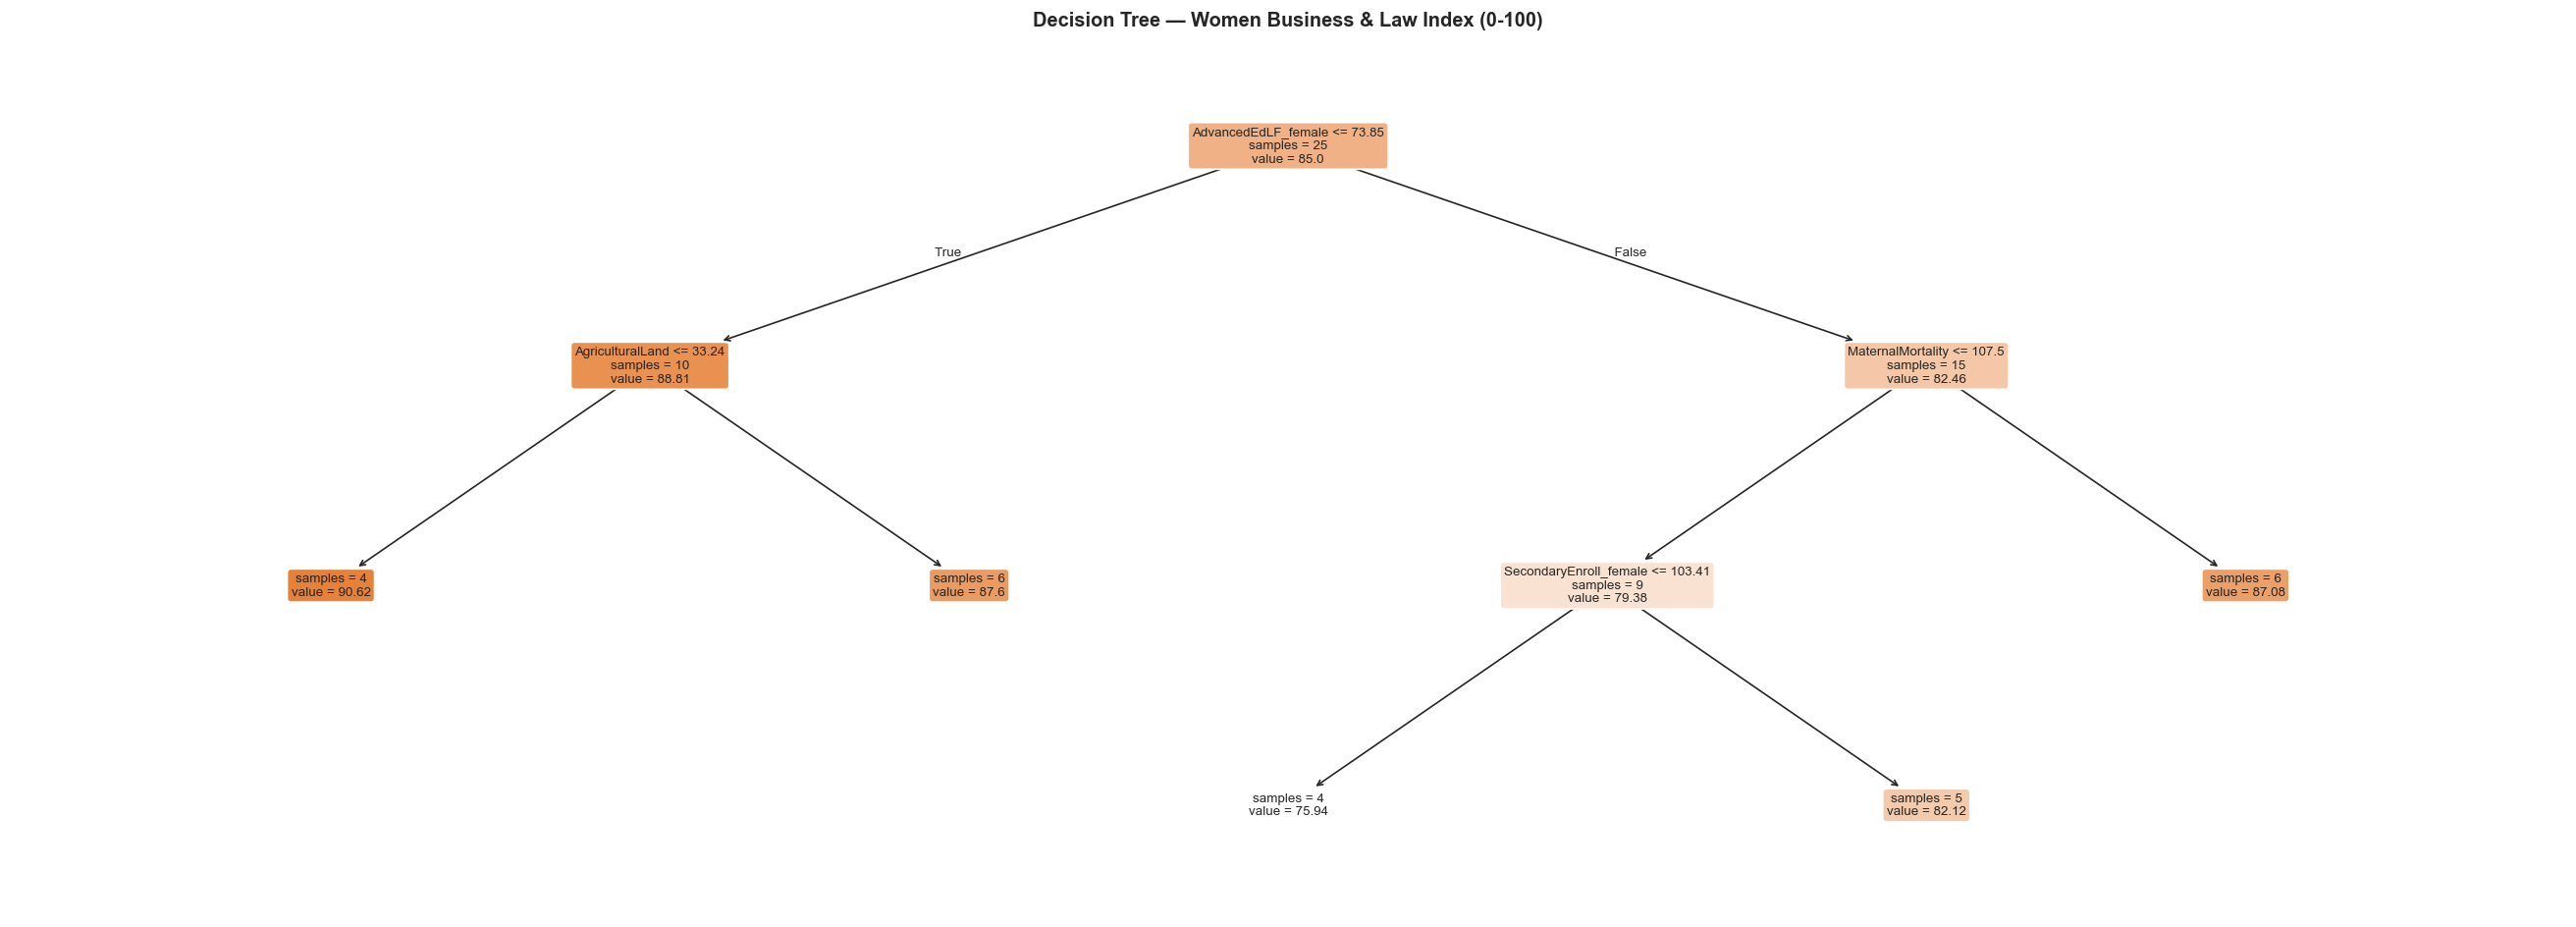


--- Rules: Women Business & Law Index (0-100) ---
|--- AdvancedEdLF_female <= 73.85
|   |--- AgriculturalLand <= 33.24
|   |   |--- value: [90.62]
|   |--- AgriculturalLand >  33.24
|   |   |--- value: [87.60]
|--- AdvancedEdLF_female >  73.85
|   |--- MaternalMortality <= 107.50
|   |   |--- SecondaryEnroll_female <= 103.41
|   |   |   |--- value: [75.94]
|   |   |--- SecondaryEnroll_female >  103.41
|   |   |   |--- value: [82.12]
|   |--- MaternalMortality >  107.50
|   |   |--- value: [87.08]



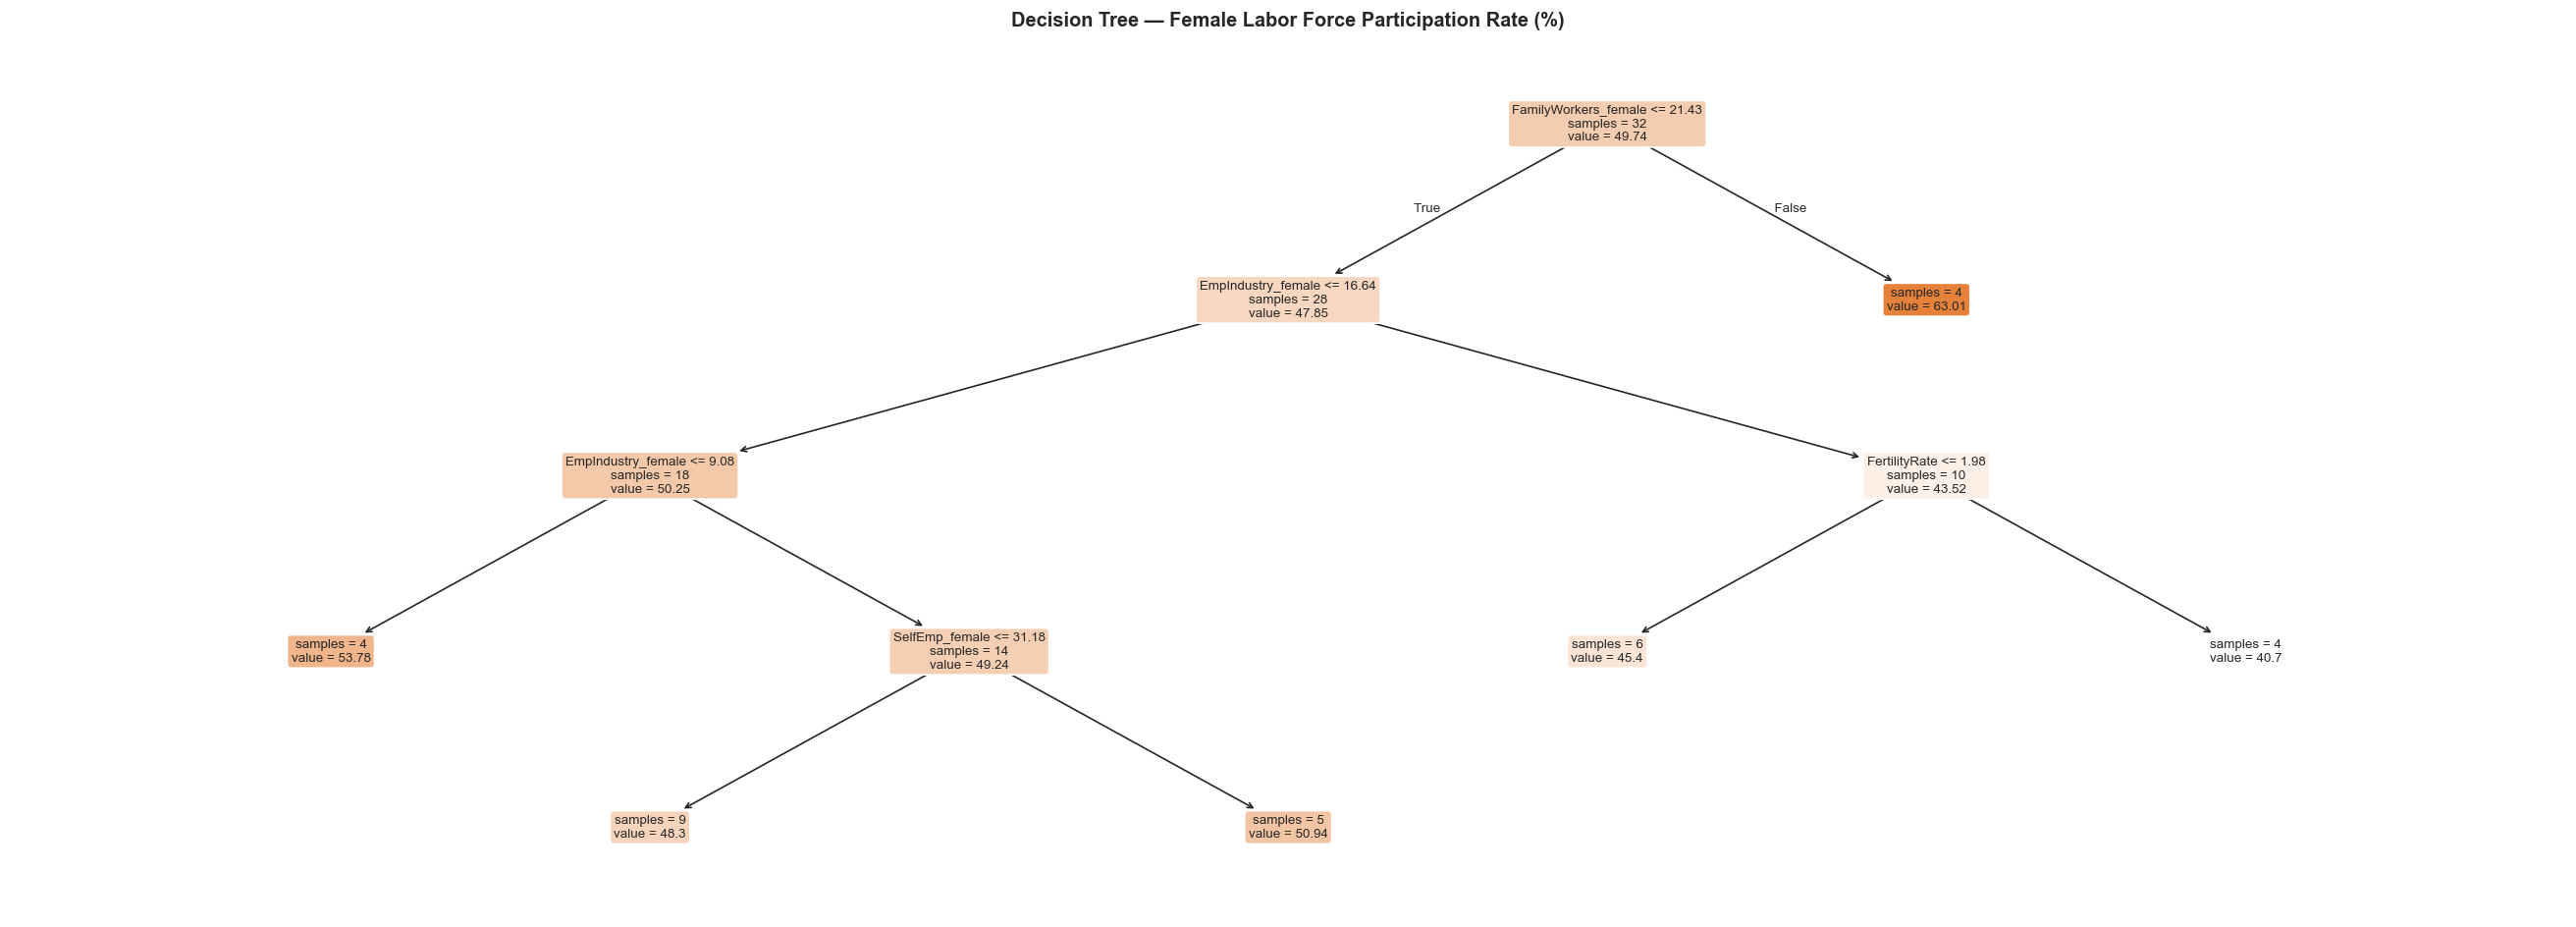


--- Rules: Female Labor Force Participation Rate (%) ---
|--- FamilyWorkers_female <= 21.43
|   |--- EmpIndustry_female <= 16.64
|   |   |--- EmpIndustry_female <= 9.08
|   |   |   |--- value: [53.78]
|   |   |--- EmpIndustry_female >  9.08
|   |   |   |--- SelfEmp_female <= 31.18
|   |   |   |   |--- value: [48.30]
|   |   |   |--- SelfEmp_female >  31.18
|   |   |   |   |--- value: [50.94]
|   |--- EmpIndustry_female >  16.64
|   |   |--- FertilityRate <= 1.98
|   |   |   |--- value: [45.40]
|   |   |--- FertilityRate >  1.98
|   |   |   |--- value: [40.70]
|--- FamilyWorkers_female >  21.43
|   |--- value: [63.01]



In [9]:
for target_key, (rf, dt, imp_df, feat_names, X, y) in results.items():
    fig, ax = plt.subplots(figsize=(22, 8))
    plot_tree(
        dt, feature_names=feat_names,
        filled=True, rounded=True,
        impurity=False, precision=2,
        ax=ax, fontsize=8,
    )
    ax.set_title(f'Decision Tree — {TARGETS[target_key]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\n--- Rules: {TARGETS[target_key]} ---')
    print(export_text(dt, feature_names=feat_names, max_depth=3))

## 7. Top Predictors Summary Table

In [10]:
TOP_N = 5
rows = []
for target_key, (rf, dt, imp_df, feat_names, X, y) in results.items():
    for rank, (_, row) in enumerate(
            imp_df[imp_df.importance_mean > 0].head(TOP_N).iterrows(), 1):
        rows.append({
            'Target':            TARGETS[target_key],
            'Rank':              rank,
            'Feature':           row.feature,
            'Importance (mean)': round(row.importance_mean, 4),
        })

summary_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 100)
summary_df

,Target,Rank,Feature,Importance (mean)
0,Female Unemployment Rate (%),1,EmpServices_female,0.2772
1,Female Unemployment Rate (%),2,FamilyWorkers_female,0.1544
2,Female Unemployment Rate (%),3,FertilityRate,0.0644
3,Female Unemployment Rate (%),4,SecondaryEnroll_female,0.0520
4,Female Unemployment Rate (%),5,AdvancedEdLF_male,0.0414
5,Female Share in Senior/Middle Mgmt (%),1,EmpAgriculture_female,0.5274
6,Female Share in Senior/Middle Mgmt (%),2,EmpServices_female,0.0901
7,Female Share in Senior/Middle Mgmt (%),3,AdvancedEdLF_male,0.0207
8,Female Share in Senior/Middle Mgmt (%),4,PartTime_female,0.0191
9,Female Share in Senior/Middle Mgmt (%),5,Literacy_male,0.0173


## 8. Cross-Target Heatmap: Feature Importance Across All Outcomes

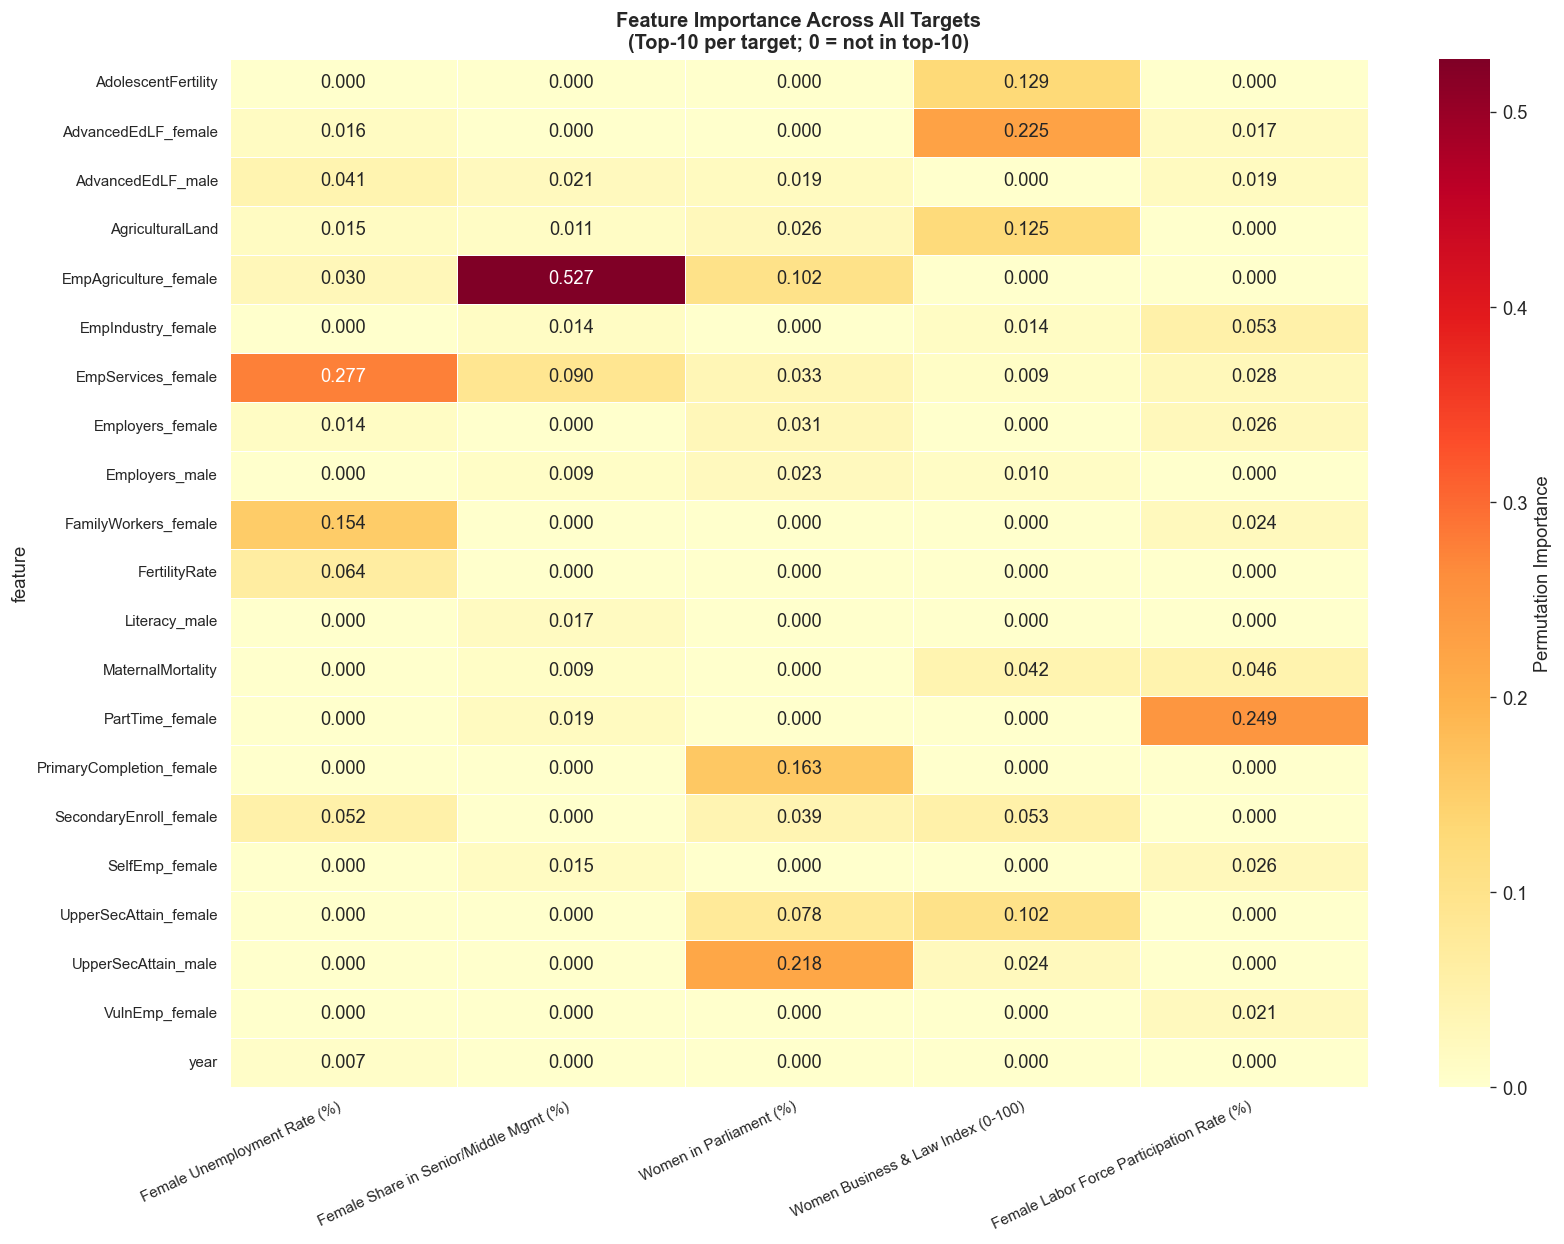

In [11]:
heatmap_data = {}
for target_key, (rf, dt, imp_df, feat_names, X, y) in results.items():
    top10 = imp_df[imp_df.importance_mean > 0].head(10)
    heatmap_data[TARGETS[target_key]] = top10.set_index('feature')['importance_mean']

heat_df = pd.DataFrame(heatmap_data).fillna(0)
heat_df = heat_df.loc[(heat_df > 0).any(axis=1)]

fig, ax = plt.subplots(figsize=(14, max(6, len(heat_df) * 0.5)))
sns.heatmap(
    heat_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Permutation Importance'},
)
ax.set_title(
    'Feature Importance Across All Targets\n(Top-10 per target; 0 = not in top-10)',
    fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 9. Partial Dependence — Female Unemployment (Top 5 Features)

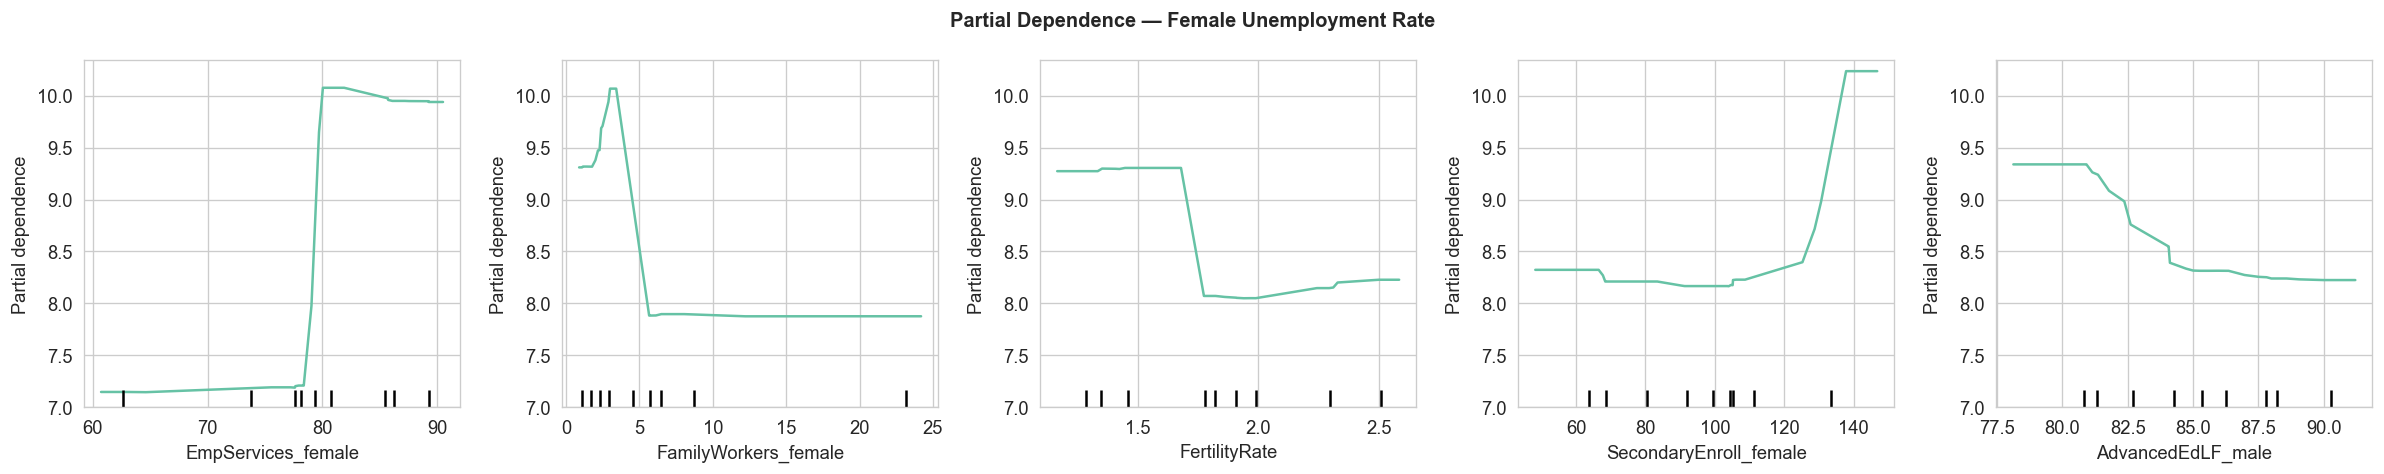

In [12]:
if 'Unemp_female' in results:
    rf, dt, imp_df, feat_names, X, y = results['Unemp_female']
    top5 = imp_df[imp_df.importance_mean > 0].head(5)['feature'].tolist()
    feat_indices = [list(feat_names).index(f) for f in top5]

    fig, axes = plt.subplots(1, len(feat_indices),
                             figsize=(4 * len(feat_indices), 4))
    if len(feat_indices) == 1:
        axes = [axes]

    PartialDependenceDisplay.from_estimator(
        rf, X, feat_indices, ax=axes,
        line_kw={'color': PALETTE[0]},
    )
    fig.suptitle('Partial Dependence — Female Unemployment Rate',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Correlation Between Target Indicators

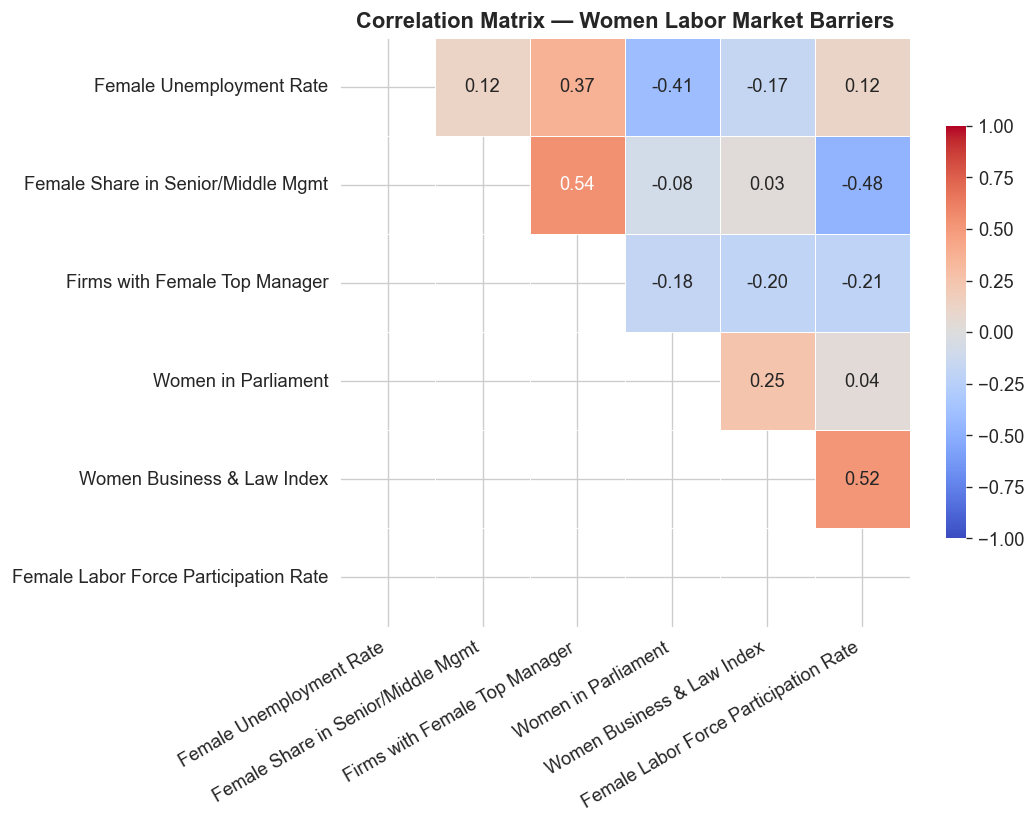

In [13]:
barrier_cols = [k for k in TARGETS.keys() if k in df.columns]
corr = df[barrier_cols].corr()
short_names = {k: v.split(' (')[0] for k, v in TARGETS.items()}
corr.index   = [short_names[k] for k in corr.index]
corr.columns = corr.index

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=~mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Correlation Matrix — Women Labor Market Barriers',
             fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Country Ranking by Target (Latest Available Year)

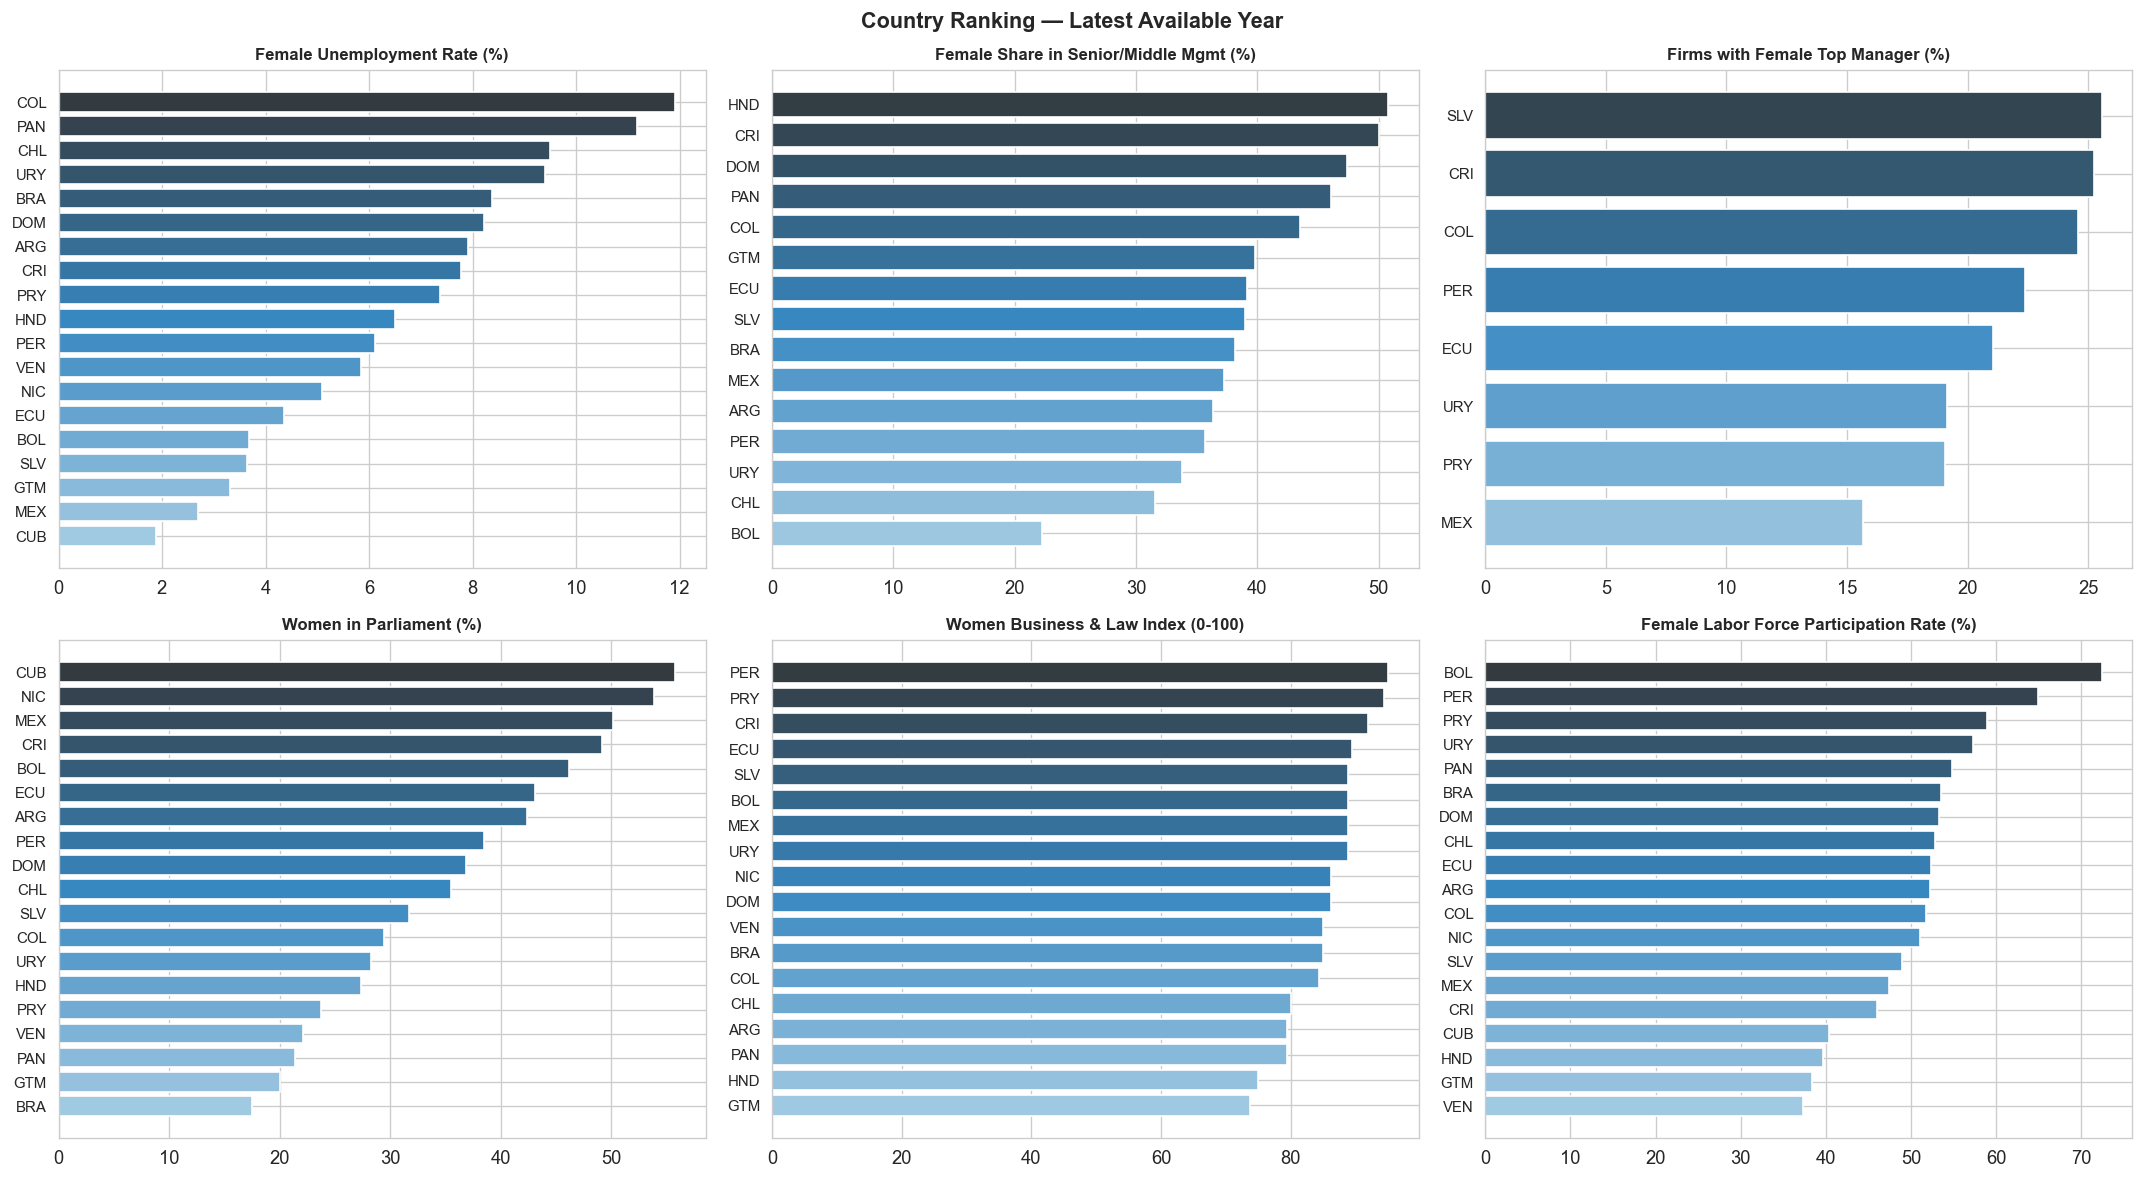

In [14]:
latest = df.sort_values('year').groupby('country_code').last().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (target_key, target_label) in enumerate(TARGETS.items()):
    if target_key not in latest.columns:
        axes[idx].set_visible(False)
        continue
    sub = latest[['country_code', target_key]].dropna() \
              .sort_values(target_key, ascending=True)
    pal = sns.color_palette('Blues_d', len(sub))
    axes[idx].barh(sub.country_code, sub[target_key], color=pal)
    axes[idx].set_title(target_label, fontsize=10, fontweight='bold')
    axes[idx].tick_params(axis='y', labelsize=9)

plt.suptitle('Country Ranking — Latest Available Year',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()